# Modeling Non-Linear Patterns with Activation Functions

## 1. Imports

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

import matplotlib.pyplot as plt

## 2. Preparing the Non-Linear Data

In [2]:
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

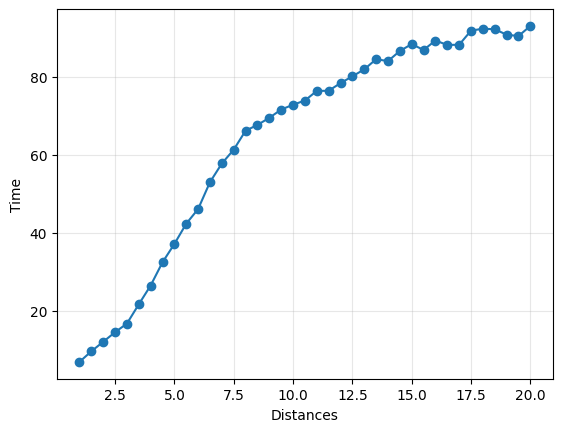

In [3]:
plt.plot(distances, times, marker='o')

plt.grid(True, alpha=.3)
plt.xlabel("Distances")
plt.ylabel("Time")

plt.show()

## 3. A new step: normalizing the Data

In [4]:
# calculate the mean and standard deviation for the 'distance' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# calculate the mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# apply standardization to the distances
distances_normalized = (distances - distances_mean) / distances_std

# apply standardization to the times
times_normalized = (times - times_mean) / times_std

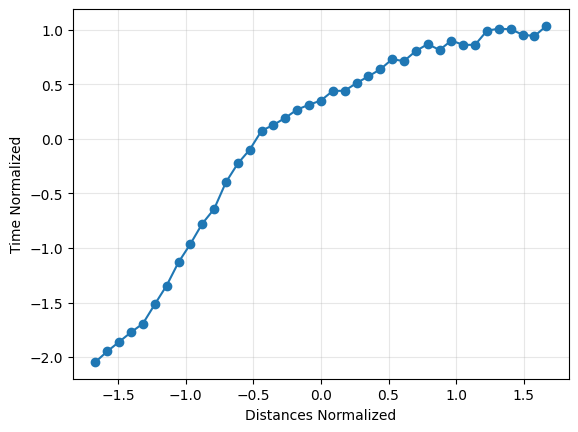

In [5]:
plt.plot(distances_normalized, times_normalized, marker='o')

plt.grid(True, alpha=.3)
plt.xlabel("Distances Normalized")
plt.ylabel("Time Normalized")

plt.show()

## 4. Building the Non-Linear Model

In [42]:
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3), # first hidden layer - one input feature and three neurons
    nn.ReLU(),
    nn.Linear(3, 1) # three input features and 1 output neuron
)

## 5. Training

In [43]:
# define the loss function and the optimizer for training
loss_func = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
print("[LOSS FUNTION AND OPTIMIZER DEFINED]")

[LOSS FUNTION AND OPTIMIZER DEFINED]


In [44]:
loss_hist = list()

for epoch in tqdm(range(3000)):

    optimizer.zero_grad()

    outputs = model(distances_normalized)

    loss = loss_func(outputs, times_normalized)

    loss.backward()

    optimizer.step()

    loss_hist.append(loss.item())

print("\n======== TRAINING COMPLETE ========")
print(f"\nFINAL LOSS: {loss.item()}")

100%|█████████████████████████████████████████████████████████████████| 3000/3000 [00:01<00:00, 2733.77it/s]


======== TRAINING COMPLETE ========

FINAL LOSS: 0.003143715439364314


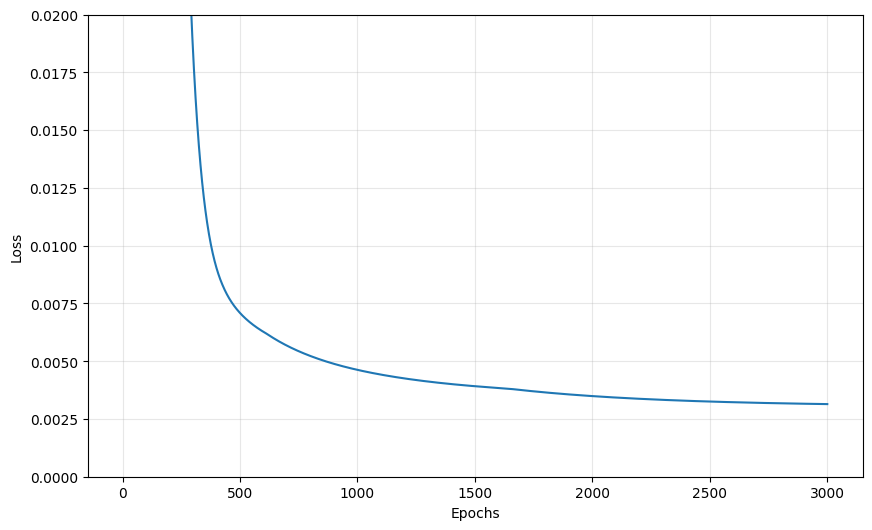

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, 3001), loss_hist)
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.ylim(0, 0.02)

plt.grid(True, alpha=.3)
plt.show()

In [46]:
predictions = model(distances_normalized).detach().numpy()

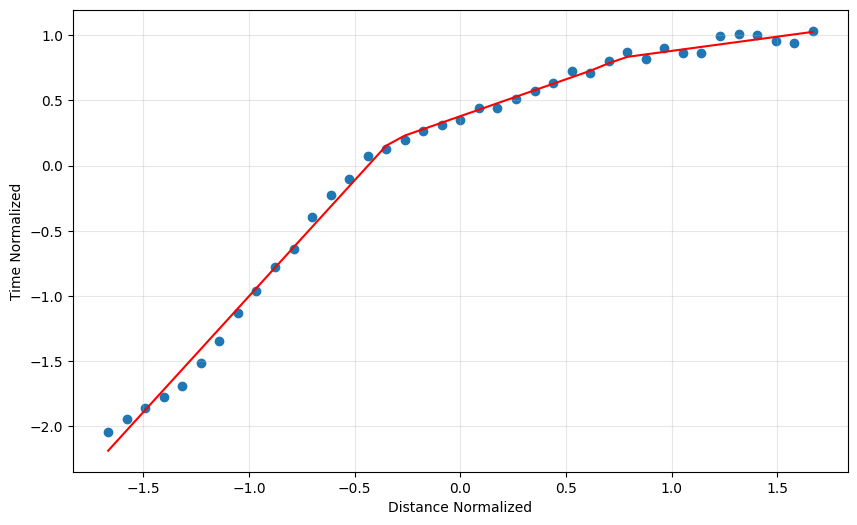

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(distances_normalized, times_normalized)
plt.plot(distances_normalized, predictions, 'r')

plt.xlabel("Distance Normalized")
plt.ylabel("Time Normalized")

plt.grid(True, alpha=.3)

plt.show()

## 6. Making a Prediction

In [48]:
distance_to_predict = 5.1

In [50]:
with torch.no_grad():

    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std

    predicted_time_norm = model(new_distance_norm)

    predicted_time_actual = (predicted_time_norm * times_std) + times_mean

    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.2f} minutes")

    if predicted_time_actual.item() > 45:
        print("DECISION: Do NOT promise the delivery under 45 minutes.")
    else:
        if distance_to_predict <= 3:
                print(f"DECISION: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"DECISION: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 38.69 minutes
DECISION: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.
